<a href="https://colab.research.google.com/github/theo-mattsa/Hands-On-Machine-Learning/blob/main/Chapter3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import fetch_openml

# Returned as sklearn.utils.Bunch object (which are dictionaries)
mnist = fetch_openml('mnist_784', as_frame=False)

In [ ]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
X, y = mnist.data, mnist.target
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (70000, 784)
y shape: (70000,)


In [ ]:
y[:5]

array(['5', '0', '4', '1', '9'], dtype=object)

There are 70k images, and each image has 784 features. This is because, each image is 28 x 28 pixels, and each feature simply represents one pixel's intensity, from 0 to 255.

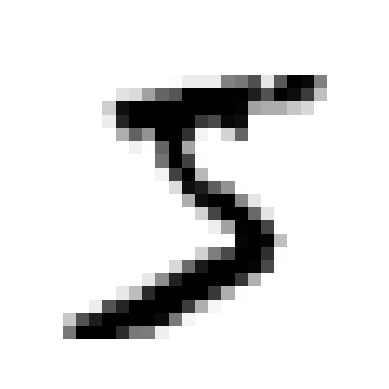

In [ ]:
from numpy import ndarray
import matplotlib.pyplot as plt

def plot_digit(image_data: ndarray):
  image = image_data.reshape(28, 28)
  # Binary to get a grayscale color map (0 is white and 255 is black)
  plt.imshow(image, cmap='binary')
  plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [ ]:
# The MNIST dataset returned by fetch_openml is actually already split
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]


## Training a Binary Classifier

In [ ]:
# Simplify for now and only try to identify one digit
y_train_5 = (y_train == '5').astype(int)
y_test_5 = (y_test == '5').astype(int)

In [ ]:
# Let's pick a classifier and train it
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([1])

## Performance Measures

### Measuring Accuracy using Cross-Validation


In [ ]:
from sklearn.model_selection import cross_val_score

# Evaluating using k-fold cross-validation with three
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.95035, 0.96035, 0.9604 ])

Wow!, Above 95% on all cross-validation folds? Let's look at dummy classifier that just classificates every single imagem in the most frequent class, which in this case is the negative class (non 5)

In [ ]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)

print(any(dummy_clf.predict(X_train))) # No 5s detected

False


In [ ]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

It has over 90% accuracy! This is simply because only about
10% of the images are 5s


## Confusion Matrices

The general idea of a confusion matrix is to count the number of times instances of class A are classified as class B, for all A/B pairs.






In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [ ]:
y_train_pred.shape

(60000,)

In [ ]:
from sklearn.metrics import confusion_matrix

# Just pass it the target classes and predict classes
cm = confusion_matrix(y_train_5, y_train_pred)


* The first row of this matrix considers
non-5 images. 53,892 of them were correctly classified as non-5s (they are called true negatives), while the remaining 687 were
wrongly classified as 5s (false positives, also called type I errors)

*  The
second row considers the images of 5s (the positive class): 1,891 were
wrongly classified as non-5s (false negatives, also called type II errors), while the remaining 3,530 were correctly classified as 5s (true positives)





In [ ]:
# Each row represents an actual class
cm

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
from sklearn.metrics import precision_score, recall_score

print(f'Precision: {precision_score(y_train_5, y_train_pred)}')
print(f'Recall: {recall_score(y_train_5, y_train_pred)}')

Precision: 0.8370879772350012
Recall: 0.6511713705958311


When it claims an image represents a 5, it is correct only 83.7% of the time. Moreover, it only detects 65.1% of the 5s.



In [ ]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [ ]:
# SGD decision scores
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [ ]:
# The SGDClassifier uses a threshold equal to 0
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [ ]:
# How do you decide which threshold to use?

# Get the scores of all instances in training set, but the decision scores instead of predictions
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [ ]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

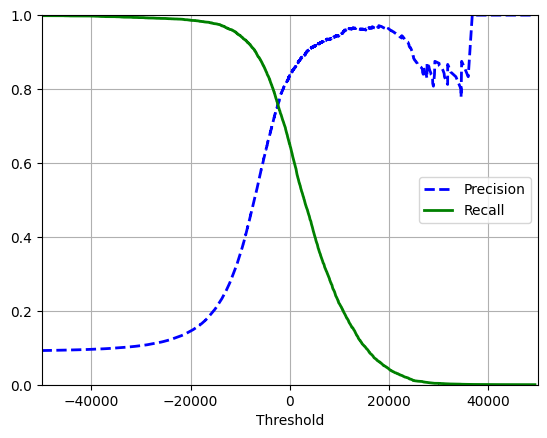

In [ ]:
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.show()

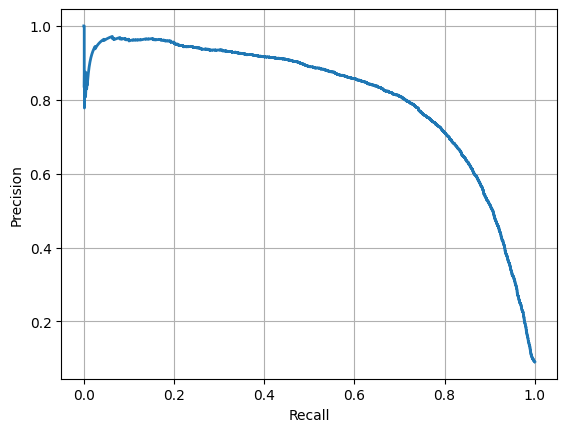

In [ ]:
# ANother way to select a good precision/recall trade-off is to plot against
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.grid()
plt.xlabel("Recall")
plt.ylabel('Precision')
plt.show()

In [ ]:
# Suppose I decide to aim for 90% precision

# Arg max return the first index of the maximum value (which in this cause first True)
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [ ]:
y_train_pred_90 = (y_scores >= thresholds[idx_for_90_precision])
print(f'Precision score: {precision_score(y_train_5, y_train_pred_90)}')
print(f'Recall score: {recall_score(y_train_5, y_train_pred_90)}')

Precision score: 0.9000345901072293
Recall score: 0.4799852425751706


In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

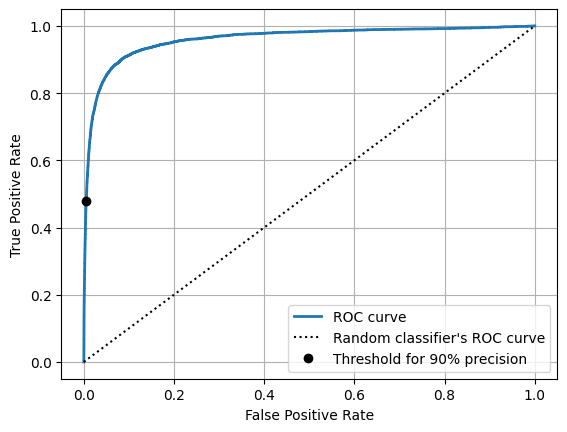

In [ ]:
# Point that corresponds to 90% precision
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

# Plot
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.grid()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

In [ ]:
# Let's now create a Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [ ]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')

In [ ]:
# The model predicts that the first image is positive with 89% probability
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [ ]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

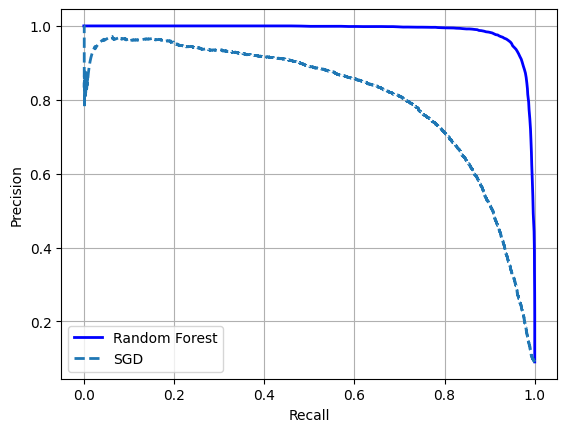

In [ ]:
plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
plt.grid()
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")

In [ ]:
y_pred_forest = y_probas_forest[:, 1] >= 0.5 # positive proba ≥ 50%
f1_score(y_train_5, y_pred_forest)

0.9274509803921569

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

## Multiclass

In [ ]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [ ]:
# Since there are 10 classes (more than 2), scikit used the OvO strategy and trained 45 classifiers
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [ ]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [ ]:
class_id = some_digit_scores.argmax()
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [ ]:
svm_clf.classes_[class_id]

'5'

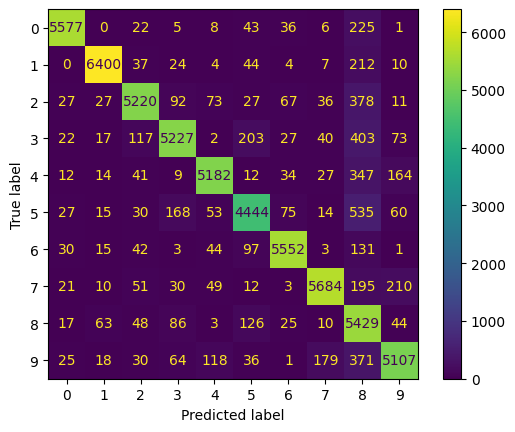

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import SGDClassifier
import numpy as np

sgd_clf = SGDClassifier(random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

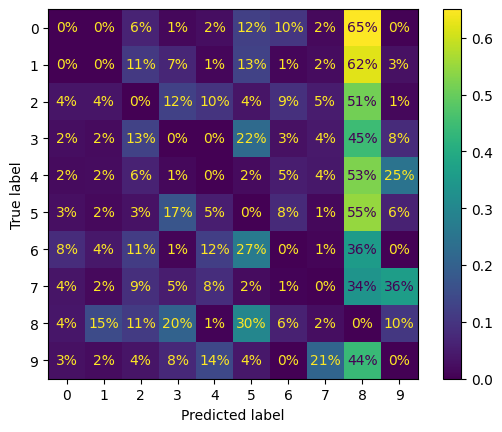

In [ ]:
# Normalized by row
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

# It means that 36% of the errors the model made on images of 7s were misclassifications as 9s

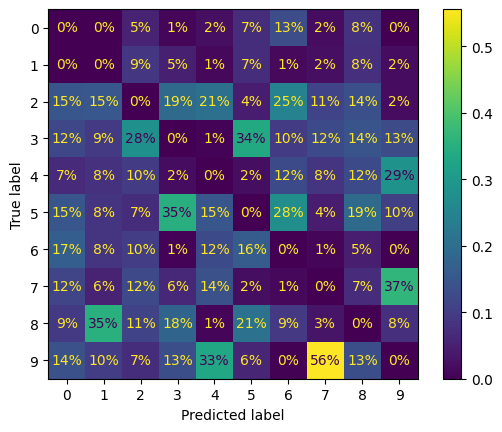

In [ ]:
# Normalized by column
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
plt.show()

# 56% of misclassified 7s are actually 9s

## Mutilabel Classification

In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

In [ ]:
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)

# Two target labels (first digit is large and second is odd or not)
y_multilabel = np.c_[y_train_large, y_train_odd]
y_multilabel

array([[False,  True],
       [False, False],
       [False, False],
       ...,
       [False,  True],
       [False, False],
       [ True, False]])

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [ ]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [ ]:
f1_score(y_multilabel, y_train_knn_pred, average='macro')

0.9764102655606048

In [ ]:
f1_score(y_multilabel, y_train_knn_pred, average='weighted')

0.9778357403921755

In [ ]:
from sklearn.multioutput import ClassifierChain
from sklearn.svm import SVC

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [ ]:
y_chain_pred = cross_val_predict(chain_clf, X_train[:2000], y_multilabel[:2000], cv=3)

## Multioutput Classification

In [ ]:
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

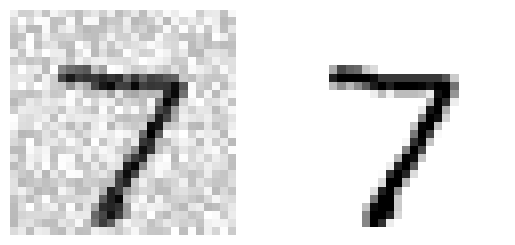

In [ ]:
plt.subplot(1, 2, 1)
plot_digit(X_test_mod[0])
plt.subplot(1, 2, 2)
plot_digit(X_test[0])
plt.show()

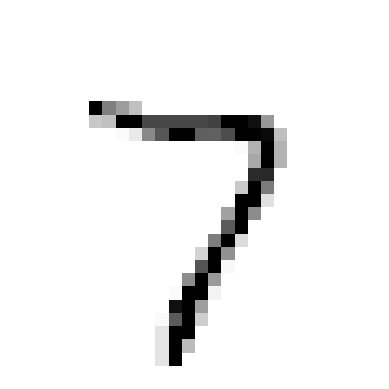

In [ ]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()